# Interpolación de Lagrange

Implementación y aplicación del **polinomio interpolante de Lagrange** para construir una función polinómica que pase exactamente por un conjunto de datos conocidos.

Este notebook reúne y organiza los ejercicios de Lagrange que estaban distribuidos en dos cuadernos diferentes, conservando los **códigos originales** y mejorando únicamente la documentación y la estructura del contenido.

### Objetivos

- Comprender el fundamento de la interpolación de Lagrange.
- Construir el polinomio interpolante a partir de un conjunto de puntos.
- Aplicar el método a datos experimentales.
- Visualizar el comportamiento del polinomio interpolante.
- Analizar cómo el grado del polinomio depende del número de datos disponibles.

**Tecnologías:** Python · NumPy · SymPy · Matplotlib

## 1. Fundamento del método

Dado un conjunto de $n+1$ puntos:

$(x_0,y_0), (x_1,y_1), \dots, (x_n,y_n)$

con valores de $x_i$ distintos entre sí, existe un único polinomio interpolante de grado **a lo sumo $n$** que pasa por todos los puntos.

El polinomio de Lagrange se expresa como:

$$
P(x)=\sum_{i=0}^{n} y_iL_i(x)
$$

donde cada polinomio base de Lagrange está definido por:

$$
L_i(x)=
\prod_{\substack{j=0 \\ j\neq i}}^{n}
\frac{x-x_j}{x_i-x_j}
$$

Cada $L_i(x)$ toma el valor $1$ en $x_i$ y $0$ en los demás nodos de interpolación. De esta manera, el polinomio resultante reproduce exactamente los valores conocidos del conjunto de datos.

## 2. Implementación del polinomio de Lagrange

La siguiente función corresponde a la implementación original del método. Utiliza **SymPy** para construir simbólicamente cada término del polinomio y finalmente expandir la expresión resultante.

In [1]:
import sympy as sp

x=sp.symbols('x')

def lagrange(x_d, y_d):
    P=0
    n=len(x_d)
    for i in range(n):
        T=1
        for j in range(n):
            if (j!=i):
                T*= (x-x_d[j]) / (x_d[i] - x_d[j])
        P+=T*y_d[i]
    return sp.expand(P)

## 3. Aplicación 1 — Temperatura de la acetona según la presión

Se dispone de información experimental sobre la temperatura de la acetona para diferentes valores de presión.

| Presión $P$ (atm) | 1 | 2 | 5 | 10 | 20 | 30 | 40 |
|---|---:|---:|---:|---:|---:|---:|---:|
| Temperatura $T$ (°C) | 56.5 | 78.6 | 113.0 | 144.5 | 181.0 | 205.0 | 214.5 |

Como se tienen **7 puntos**, el polinomio interpolante puede tener grado máximo $6$.

A continuación se construye el polinomio de Lagrange correspondiente a estos datos.

In [2]:
import numpy as np

x_data = np.array([1, 2, 5, 10, 20, 30, 40])
y_data = np.array([56.5, 78.6, 113, 144.5, 181, 205, 214.5])

lagrange(x_data, y_data)

-8.09043220340857e-6*x**6 + 0.000882197061693429*x**5 - 0.0359354052488648*x**4 + 0.690577561738857*x**3 - 6.70417520231835*x**2 + 37.8906753418323*x + 24.6579835973666

### Interpretación

El resultado obtenido corresponde a un polinomio que pasa exactamente por los siete pares de presión y temperatura proporcionados.

La interpolación permite estimar valores de temperatura para presiones ubicadas dentro del intervalo de datos observado. Al utilizar un polinomio de grado relativamente alto, conviene tener precaución al realizar estimaciones fuera de dicho intervalo.

## 4. Aplicación 2 — Contador de lectura de una grabadora

Se registraron valores del contador de lectura de una grabadora junto con el tiempo transcurrido de uso.

| Contador $c_i$ | 100 | 200 | 300 | 400 | 500 | 600 | 700 | 800 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Tiempo $t_i$ | 205 | 430 | 677 | 945 | 1233 | 1542 | 1872 | 2224 |

En esta sección se utiliza únicamente la parte del ejercicio correspondiente a **interpolación de Lagrange**. Los apartados relacionados con mínimos cuadrados e interpolación polinomial simple se trabajan de forma independiente en otros notebooks del repositorio.

Primero se visualizan los datos observados.

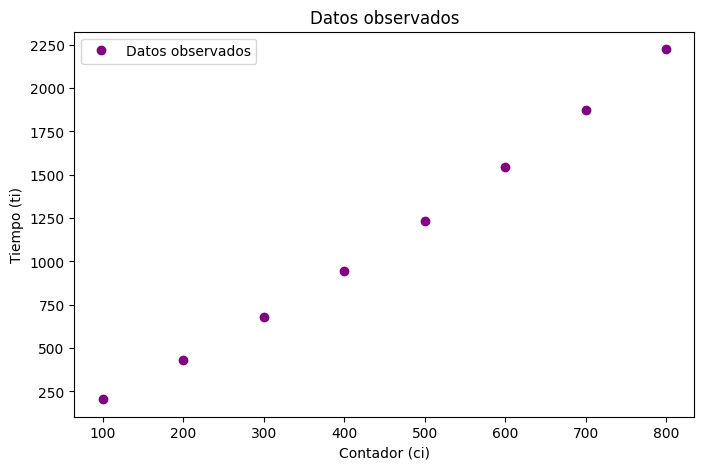

In [3]:
# Gráfica de datos observados

import numpy as np
import matplotlib.pyplot as plt

# Datos
x_data = np.array([100, 200, 300, 400, 500, 600, 700, 800])
y_data = np.array([205, 430, 677, 945, 1233, 1542, 1872, 2224])

# Gráfica solo con puntos
plt.figure(figsize=(8,5))
plt.plot(x_data, y_data, 'o', color='purple', label='Datos observados')
plt.xlabel('Contador (ci)')
plt.ylabel('Tiempo (ti)')
plt.title('Datos observados')
plt.legend()
plt.show()

### Construcción y gráfica del polinomio interpolante

Con los ocho puntos disponibles se construye el polinomio de Lagrange y posteriormente se convierte la expresión simbólica en una función numérica para representarla gráficamente junto con los datos originales.

Con **8 puntos**, el grado máximo del polinomio interpolante es $7$.

x**7/50400000000000000 - x**6/16000000000000 + 577*x**5/7200000000000 - 257*x**4/4800000000 + 2849*x**3/144000000 - 349*x**2/120000 + 97823*x/42000 - 14


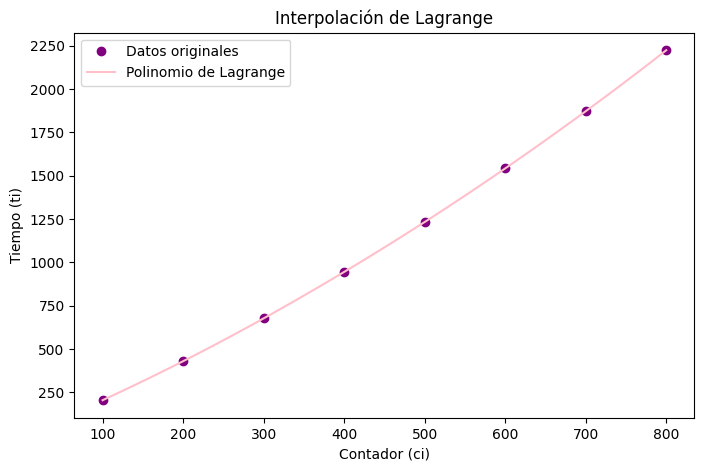

In [4]:
# Construcción del polinomio de Lagrange
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x = sp.symbols('x')

# Función de Lagrange
def lagrange(x_d, y_d):
    P = 0
    n = len(x_d)
    for i in range(n):
        T = 1
        for j in range(n):
            if j != i:
                T *= (x - x_d[j]) / (x_d[i] - x_d[j])
        P += T * y_d[i]
    return sp.expand(P)

# Datos
x_data = np.array([100, 200, 300, 400, 500, 600, 700, 800])
y_data = np.array([205, 430, 677, 945, 1233, 1542, 1872, 2224])

# Polinomio de Lagrange
P = lagrange(x_data, y_data)
print(P)

# Convertir el polinomio a función numérica para graficar
f = sp.lambdify(x, P, 'numpy')

# Rango de valores para la curva
x_vals = np.linspace(min(x_data), max(x_data), 400)
y_vals = f(x_vals)

# Gráfica
plt.figure(figsize=(8,5))
plt.plot(x_data, y_data, 'o', color='purple', label='Datos originales')
plt.plot(x_vals, y_vals, '-', color='pink', label='Polinomio de Lagrange')
plt.xlabel('Contador (ci)')
plt.ylabel('Tiempo (ti)')
plt.title('Interpolación de Lagrange')
plt.legend()
plt.show()

### Interpretación de la gráfica

La curva del polinomio interpolante pasa por los puntos utilizados en su construcción. Esto es una característica fundamental de la interpolación: el objetivo no es aproximar los datos de manera global, sino construir un polinomio que reproduzca exactamente los valores conocidos.

La representación gráfica permite observar el comportamiento del polinomio entre los diferentes valores del contador de lectura.

## 5. Conclusiones

A partir de los ejercicios desarrollados se puede concluir que:

- La interpolación de Lagrange permite construir un único polinomio que pasa por todos los puntos de un conjunto de datos con abscisas distintas.
- Con $n+1$ puntos, el grado máximo del polinomio interpolante es $n$.
- La formulación de Lagrange evita resolver explícitamente un sistema lineal para encontrar los coeficientes del polinomio.
- SymPy facilita la construcción simbólica y expansión del polinomio interpolante.
- La interpolación reproduce exactamente los datos conocidos, a diferencia de métodos de ajuste como mínimos cuadrados.
- Los polinomios de grado elevado deben utilizarse con precaución fuera del intervalo de interpolación.